## Importing Libraries

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import time 
import shap
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance , PartialDependenceDisplay 

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize']=(12,6)
df = pd.read_csv("titanic.csv")
df.columns= df.columns.str.strip().str.lower()
print(df.shape)

(1000, 7)


In [3]:
features = [
    "pclass","sex_male","age","sibsp","parch","fare"
]
target = "survived"


#### Data Cleaning

In [4]:
df["age"] = df.groupby(["pclass","sex"])["age"].transform(lambda x : x.fillna(x.median()))

df["fare"] = df["fare"].fillna(df["fare"].median())

df["sex_male"] = (df["sex"] == "male"  ).astype(int)


#### split the dataset

In [5]:


if "embarked" in df.columns:
    df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
    df["embarked_Q"] = (df["embarked"] == "Q").astype(float)
    df["embarked_S"] = (df["embarked"] == "S").astype(float)
    features += ["embarked_Q", "embarked_S"]

y = df[target]

X = df[features].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


#### Train XGB model 

In [6]:
xgb_model = xgb.XGBClassifier(
    n_estimators = 300,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="logloss",
    random_state = 42
).fit(X_train , y_train)

xgb_auc = roc_auc_score(
    y_test,
    xgb_model.predict_proba(X_test)[:,1])


print(f"XGBoost Test ROC-AUC : {xgb_auc:.4f} " )

XGBoost Test ROC-AUC : 0.8511 


## TASK 01 — Establish the global picture first

•	Compute permutation importance on the test set with n_repeats=20 and scoring='roc_auc'.

In [8]:

perm = permutation_importance(xgb_model, X_test,y_test, n_repeats=20, random_state=42, scoring="roc_auc")


•	Rank the features and plot them as a horizontal bar chart.

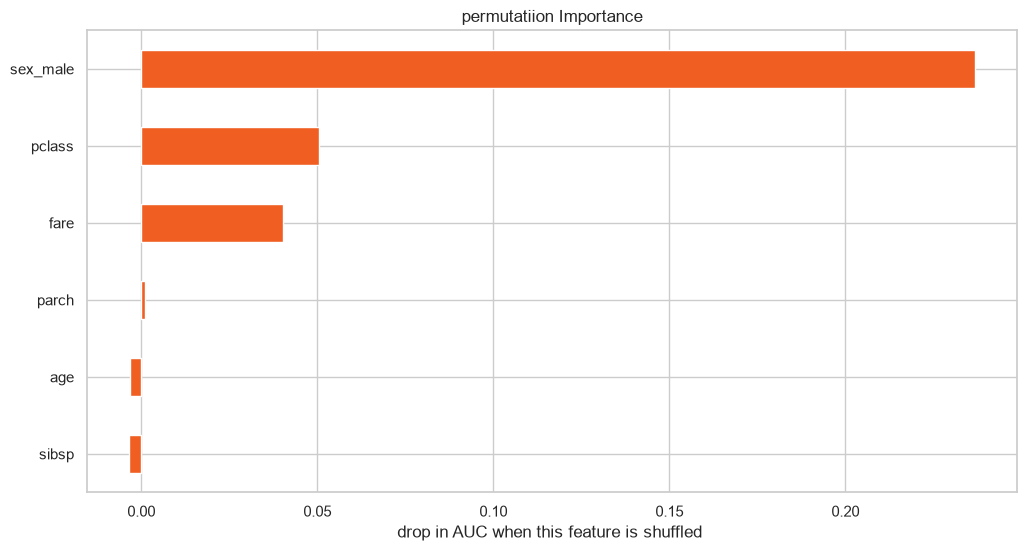

In [9]:
global_importance = pd.Series(perm.importances_mean,index = features).sort_values(ascending=False)

fig,ax = plt.subplots()
global_importance.plot(kind="barh", ax=ax, color="#F05E22")
ax.set_xlabel("drop in AUC when this feature is shuffled ")
ax.set_title("permutatiion Importance")
ax.invert_yaxis()


•	Write one sentence naming the top three drivers in order.

==>The Top 3 drivers are sex_male , pclass ,fare  

•	Answer in Markdown: name one question about your model that this ranking CANNOT answer.

==>  Which feature is responsible for increasing or decreasing the prediction for an individual passenger

## TASK 02 — Prove local accuracy yourself

•	Create a shap.TreeExplainer for your model and compute SHAP values for the test set.

In [10]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)


•	Print the shape of the SHAP values array and explain in one line why it has that shape.

In [11]:
print(f"Shap Values shape :{shap_values.shape}")

print ("because in feature there is one shap value per  feature per row Thats why it has shape ")

Shap Values shape :(200, 6)
because in feature there is one shap value per  feature per row Thats why it has shape 


•	Print the explainer's expected_value and state in your own words what it represents.

==> **Expected Value:** It represents the model’s **average prediction (baseline output)**. It is the starting point before SHAP values show how each feature changes the prediction.

•	For any three different rows, show that base value + sum of that row's SHAP values equals the model's raw output from model.predict(X, output_margin=True)

•	Use np.isclose to confirm the match programmatically rather than by eye

In [12]:
for row in [45, 11, 32]:
    raw_output = xgb_model.predict(X_test, output_margin=True)[row]
    shap_sum = explainer.expected_value + shap_values[row].sum()

    print(f"Row {row}:")
    print(f"Base value + SHAP sum = {shap_sum:.6f}")
    print(f"Model raw output       = {raw_output:.6f}")
    print(f"Match: {np.isclose(shap_sum, raw_output)}")
    print()

Row 45:
Base value + SHAP sum = -2.275258
Model raw output       = -2.275257
Match: True

Row 11:
Base value + SHAP sum = 2.842869
Model raw output       = 2.842868
Match: True

Row 32:
Base value + SHAP sum = 1.426350
Model raw output       = 1.426350
Match: True



## TASK 03 — Summary and beeswarm

•	Create the bar summary plot (plot_type='bar') and the beeswarm summary plot.

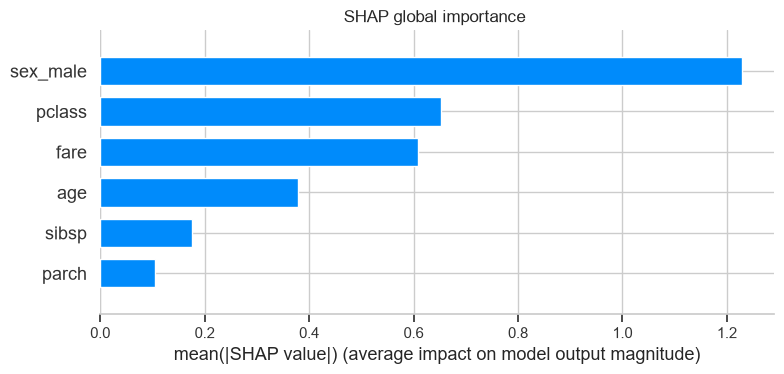

In [13]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP global importance ')
plt.tight_layout(); plt.show()

•	Compare the SHAP bar ranking against your permutation ranking from Task 01. Note any differences.

==> **Comparison:** Both methods rank `sex_male`, `pclass`, and `fare` as the top three features. However, SHAP ranks `age`, `sibsp`, and `parch` as more influential, while permutation importance shows these features having very small or slightly negative importance.

#### Beeswarm

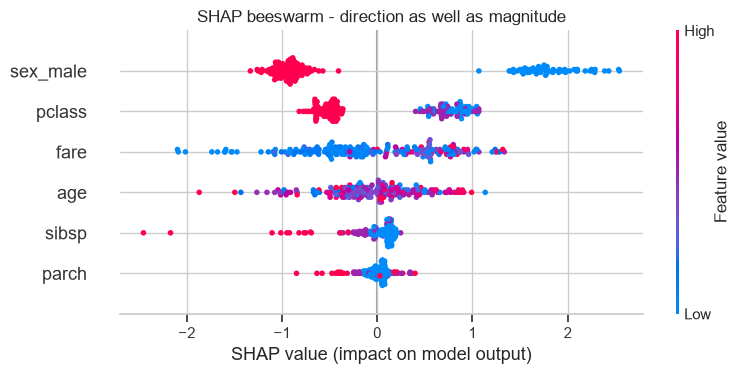

In [14]:
shap.summary_plot(shap_values, X_test,show=False)
plt.title("SHAP beeswarm - direction as well as magnitude")
plt.tight_layout(); plt.show()

•	From the beeswarm ONLY, state for each of your top two features whether high values push predictions up or down — and say which visual cue told you.

== > 
 **sex_male:** High values push predictions **down**.  
  **Cue:** Red (high) points are mostly on the **negative SHAP value** side.

- **pclass:** High values push predictions **down**.  
  **Cue:** Red (high) points are mainly on the **negative SHAP value** side.

•	Explain in two sentences what information the beeswarm shows that the bar chart discards.

The beeswarm shows the **direction and distribution of each feature’s impact** across individual predictions. The bar chart only shows the **average magnitude of importance**, so it discards direction and individual variation.

## TASK 04 — Explain three individual passengers

•	Compute predicted probabilities and programmatically select three rows: the most confident survival, the most confident death, and the prediction closest to 0.50.

In [15]:
probabilities = xgb_model.predict_proba(X_test)[:, 1]

most_confident_survivor = int(np.argmax(probabilities))
most_confident_death = int (np.argmin(probabilities))
most_uncertain = int (np.argmin(np.abs(probabilities-0.5)))

•	For each, print the passenger's feature values and the predicted probability.

In [16]:
for labels , idx  in [("most_confident_survived" , most_confident_survivor),
                        ("most_confident_death" , most_confident_death),
                        ("most_uncertain", most_uncertain)]:
    print(f"{labels} rows {idx:3} p(survive) = {probabilities[idx]:.3f} actual = {y_test.iloc[idx]}")
    print(f"   {dict(X_test.iloc[idx].astype(float).round(1))}")

most_confident_survived rows 133 p(survive) = 0.994 actual = 1
   {'pclass': np.float64(1.0), 'sex_male': np.float64(0.0), 'age': np.float64(36.5), 'sibsp': np.float64(0.0), 'parch': np.float64(0.0), 'fare': np.float64(80.3)}
most_confident_death rows 103 p(survive) = 0.003 actual = 0
   {'pclass': np.float64(3.0), 'sex_male': np.float64(1.0), 'age': np.float64(22.6), 'sibsp': np.float64(4.0), 'parch': np.float64(0.0), 'fare': np.float64(7.7)}
most_uncertain rows 136 p(survive) = 0.499 actual = 0
   {'pclass': np.float64(3.0), 'sex_male': np.float64(0.0), 'age': np.float64(23.6), 'sibsp': np.float64(0.0), 'parch': np.float64(0.0), 'fare': np.float64(22.3)}


•	Produce a SHAP waterfall plot for each of the three.

In [17]:
def waterfall(idx,title):
    exp = shap.Explanation(
        values = shap_values[idx],
        base_values = float(explainer.expected_value),
        data = X_test.iloc[idx].values,
        feature_names = features
    )
    shap.plots.waterfall(exp,show=False)
    plt.title(title)
    plt.tight_layout(); plt.show()
    

•	For each passenger, write two or three sentences explaining the prediction in plain language, as if to a colleague who has never used SHAP.

**For Most Confident Survived**

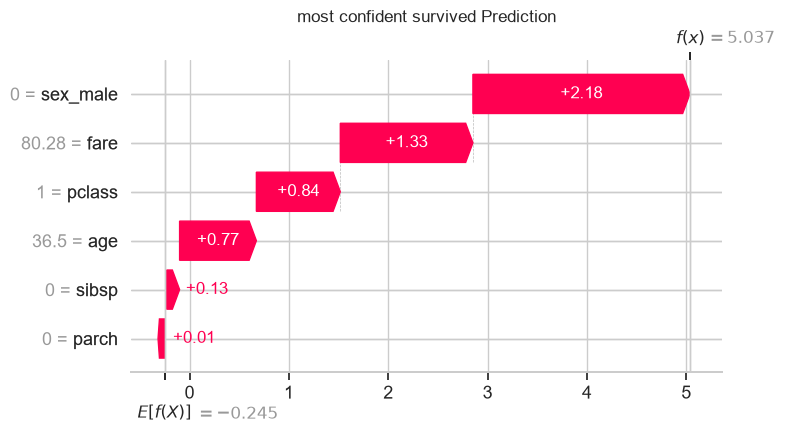

In [18]:
waterfall(most_confident_survivor , "most confident survived Prediction")

==> For **Most Confident Survived Passanger** there is huge effect of that pessenger is female , and fare paid is high , and passenger class also the impact on the prediction this three things mostly affect on it  

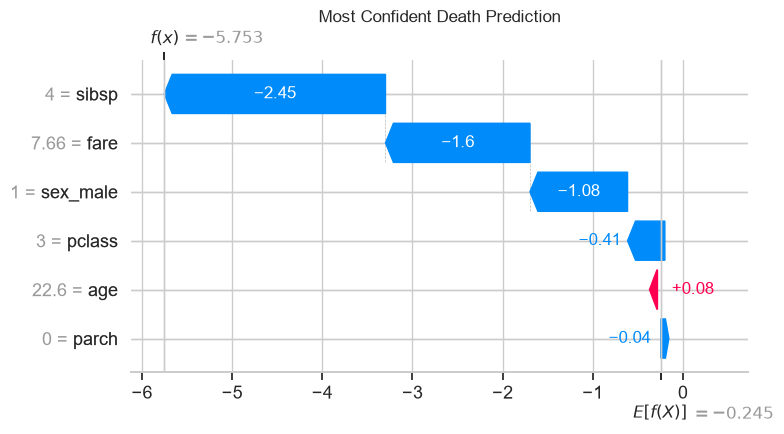

In [19]:
waterfall(most_confident_death , " Most Confident Death Prediction " )

==> For **Most Confident death prediction person** mostly affected feature or facor is passenger has high no of sibling spouch . passenger paid lowest fare and passanger is male . also passenger class is 3 .  

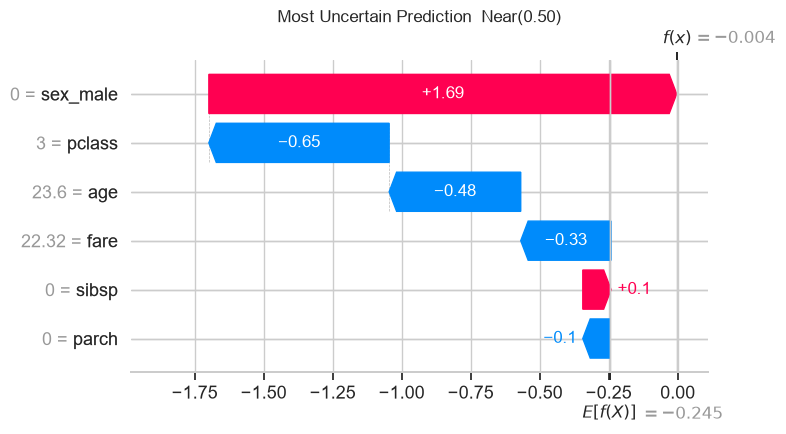

In [20]:
waterfall(most_uncertain , "Most Uncertain Prediction  Near(0.50)")

==> For **MMost Uncertain prediction passanger** there graph shows the both side like passanger is female , so it gives positive impact while passenger class is 3 so gets negative prediction and age 23.6 which is lower ...

•	For the uncertain passenger specifically, state whether the features disagree with each other, and quote the SHAP values that show it

## TASK 05 — Dependence plot

•	Create SHAP dependence plots for your top two features.

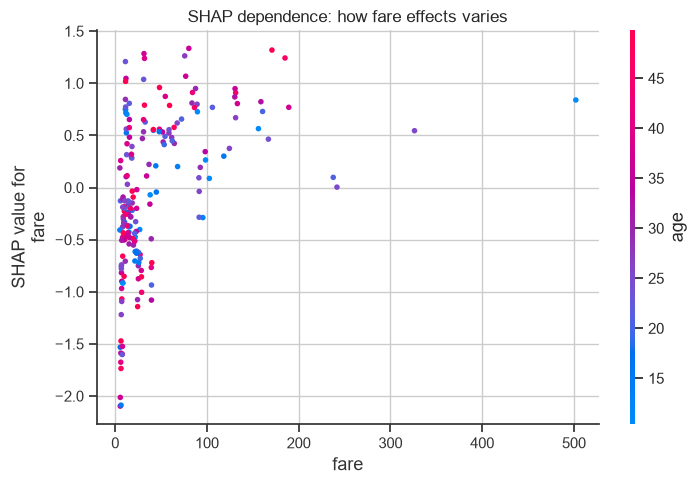

In [21]:
shap.dependence_plot("fare", shap_values,X_test,show=False)
plt.title("SHAP dependence: how fare effects varies")
plt.tight_layout(); plt.show()

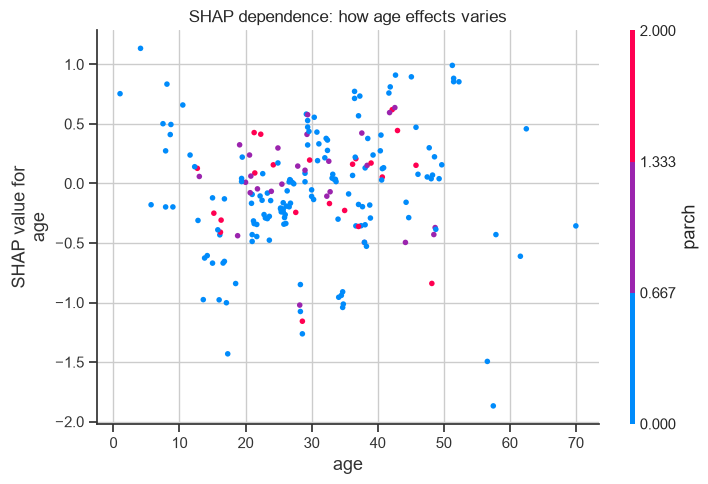

In [22]:
shap.dependence_plot("age", shap_values,X_test,show=False)
plt.title("SHAP dependence: how age effects varies")
plt.tight_layout(); plt.show()

•	Describe the shape of each in one sentence — is it linear, rising then flattening, or something else?

•	SHAP auto-selects a colouring feature. Name which one it picked for each plot and explain what that choice suggests about feature interaction.

•	Identify one region of the x-axis where dots at the same position have noticeably different SHAP values, and explain what that spread means.


### SHAP Dependence Plot

- **Fare:** The pattern is **rising and then generally flattening**, although there is considerable spread at lower fare values.

  **Colouring feature:** `age` — this suggests that the effect of `fare` can vary depending on the passenger's age.

- **Age:** The pattern is **irregular/scattered**, with SHAP values varying considerably across different ages rather than following a simple linear trend.

  **Colouring feature:** `parch` — this suggests that the effect of `age` may depend on the number of parents/children (`parch`).

- **Region showing interaction:** In the `fare` plot, around **fare = 0–50**, dots at similar fare values have SHAP values ranging from strongly negative to positive. This spread means that the effect of the same fare value differs across passengers, suggesting an interaction with another feature such as `age`.

## TASK 06 — Build PDPs and compare them to SHAP

•	Build partial dependence plots for your top three features using PartialDependenceDisplay.

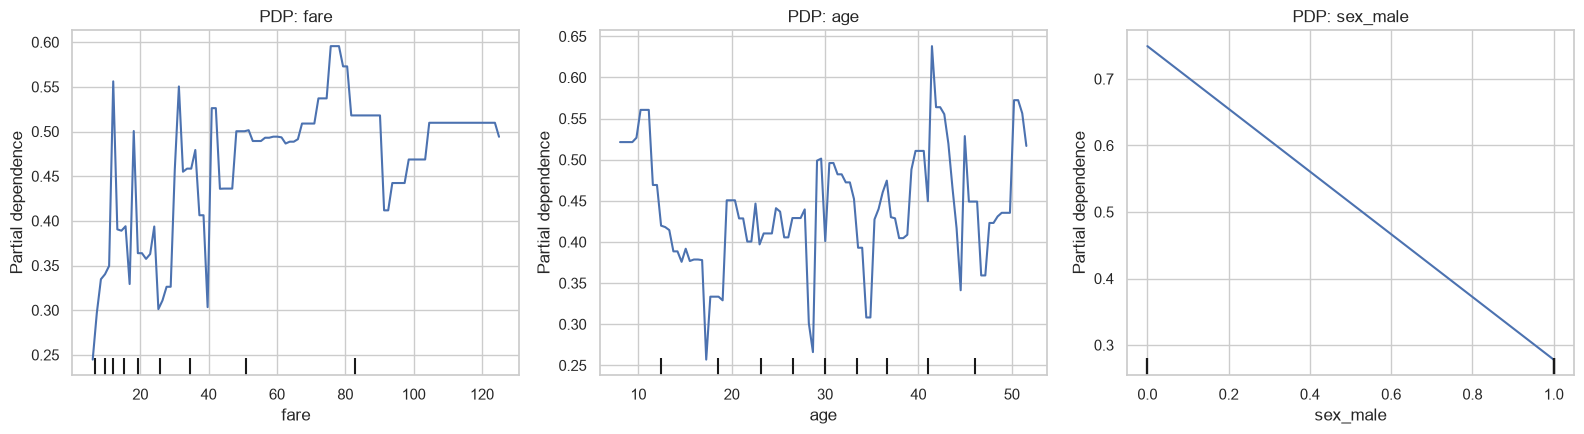

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
PartialDependenceDisplay.from_estimator(xgb_model, X_train, ["fare"], ax=axes[0])
axes[0].set_title("PDP: fare")
PartialDependenceDisplay.from_estimator(xgb_model, X_train, ["age"], ax=axes[1])
axes[1].set_title("PDP: age")
PartialDependenceDisplay.from_estimator(xgb_model, X_train, ["sex_male"], ax=axes[2])
axes[2].set_title("PDP: sex_male")
plt.tight_layout(); plt.show()

•	Build a two-feature PDP (pass a tuple of two features) and describe what the contour shows.


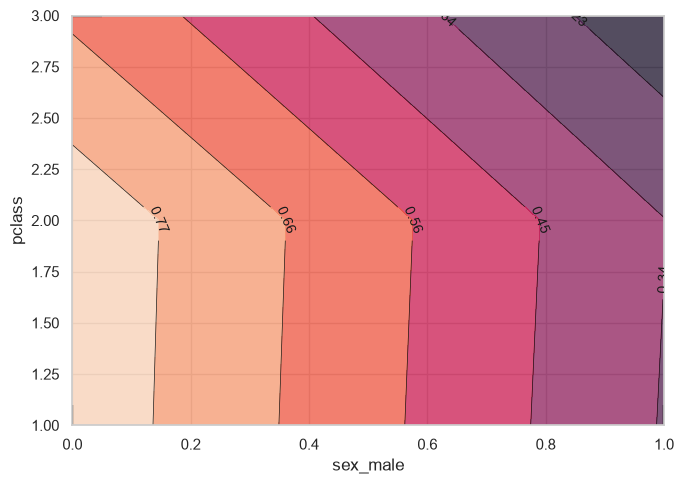

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))

PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_train,
    [("sex_male", "pclass")],
    ax=ax
)

plt.tight_layout()
plt.show()

==> he contour shows the model's average prediction for combinations of sex_male and pclass. Different regions of the contour represent different levels of predicted output, helping you see how the two features behave together.

•	Fill in a comparison table with rows for: what each dot or line represents, whether spread is visible, whether interactions are visible, and which is easier for a non-technical reader.



| | SHAP dependence | PDP |
|---|---|---|
| Shows | one dot per row | a single averaged line |
| Reveals spread | yes — you see variation | no — averaged away |
| Reveals interactions | yes, via colour | hidden by averaging |
| Easier to read | more crowded | cleaner |


## TASK 07 — Correlated features split the credit

•	Record fare's mean absolute SHAP value from your original model.

In [25]:
imp_before = pd.Series(np.abs(shap_values).mean(axis=0), index = features)


print(f"Before Duplication Fare: {imp_before['fare']:.4f}")


Before Duplication Fare: 0.6082


•	Create a near-duplicate column: fare_copy = fare plus a tiny amount of random noise. Confirm the correlation is above 0.99.

•	Retrain an identical model on the features plus fare_copy, and recompute SHAP values.

•	Report fare's importance before, and fare and fare_copy's importances after, plus their sum.


In [26]:
rng = np.random.default_rng(0)
X_train_dup = X_train.copy()
X_test_dup = X_test.copy()
X_train_dup["fare_copy"] = X_train_dup["fare"] + rng.normal(0, 0.01, len(X_train_dup))
X_test_dup["fare_copy"] = X_test_dup["fare"] + rng.normal(0, 0.01, len(X_test_dup))

print(f"correlation between fare and fare_copy: {X_train_dup[['fare','fare_copy']].corr().iloc[0,1]:.4f}")

model_dup = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3,

                              eval_metric="logloss", random_state=42).fit(X_train_dup, y_train)
shap_dup = shap.TreeExplainer(model_dup).shap_values(X_test_dup)
imp_after = pd.Series(np.abs(shap_dup).mean(axis=0), index=list(X_train_dup.columns))

print(f"\nBEFORE duplication:  fare = {imp_before['fare']:.4f}")
print(f"AFTER duplication:   fare = {imp_after['fare']:.4f}")
print(f"                fare_copy = {imp_after['fare_copy']:.4f}")
print(f"                    total = {imp_after['fare'] + imp_after['fare_copy']:.4f}")

correlation between fare and fare_copy: 1.0000

BEFORE duplication:  fare = 0.6082
AFTER duplication:   fare = 0.3899
                fare_copy = 0.3250
                    total = 0.7149


•	State plainly what happened to fare's apparent importance, even though the information available to the model did not change.

==> **Result:** The apparent importance of `fare` decreased from **0.6082** to **0.3899** after adding `fare_copy`. The importance was split between `fare` and `fare_copy` (`0.3899 + 0.3250 = 0.7149`), even though they contain essentially the same information because their correlation is **1.0000**.

## TASK 08 — Measure the computational cost

•	Time TreeExplainer on your full test set and report milliseconds per row.

•	Time KernelExplainer on a small subset (30 rows is enough) and report milliseconds per row.

•	Compute the per-row ratio between the two.


In [27]:
start = time.time()
shap.TreeExplainer(xgb_model).shap_values(X_test)
tree_time = time.time() - start

subset = X_test.iloc[:30]
start = time.time()
kernel_explainer = shap.KernelExplainer(lambda d: xgb_model.predict_proba(d)[: , 1] , shap.sample(X_train , 50)) 
kernel_explainer.shap_values(subset,nsamples=100,silent=True)
kernel_time = time.time() - start

print (f"TreeExplainer , {len(X_test)} rows: {tree_time:.3f}s  ({tree_time/len(X_test)*1000:.2f} ms/row)")
print(f"KernelExplainer,  {len(subset)} rows: {kernel_time:.3f}s  ({kernel_time/len(subset)*1000:.2f} ms/row)")
print(f"\nper row, KernelExplainer is roughly {(kernel_time/len(subset))/(tree_time/len(X_test)):.0f}x slower")

TreeExplainer , 200 rows: 0.063s  (0.31 ms/row)
KernelExplainer,  30 rows: 0.191s  (6.37 ms/row)

per row, KernelExplainer is roughly 20x slower


•	Estimate how long KernelExplainer would take on 100,000 rows at that rate, and state the answer in hours or days rather than seconds

In [28]:
# Use the measured 30-row result
time_per_row = 0.234 / 30

estimated_seconds = time_per_row * 100_000
estimated_hours = estimated_seconds / 3600
estimated_days = estimated_hours / 24

print(f"Estimated time for 100,000 rows: "
      f"{estimated_hours:.2f} hours ({estimated_days:.2f} days)")

Estimated time for 100,000 rows: 0.22 hours (0.01 days)


## TASK 09 — Write the interpretation paragraph

In [29]:
top3 = pd.Series(np.abs(shap_values).mean(axis=0), index=features).sort_values(ascending=False).head(3)
print("evidence for the paragraph below:")
print(top3.round(4))
print(f"\nbase value (average log-odds): {float(explainer.expected_value):.4f}")
print(f"model test AUC: {roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]):.4f}")

evidence for the paragraph below:
sex_male    1.2287
pclass      0.6531
fare        0.6082
dtype: float32

base value (average log-odds): -0.2446
model test AUC: 0.8511


The model achieved a test AUC of **0.8511**. The top three drivers were **sex_male (1.2287), which pushed predictions down when the value was high; pclass (0.6531), where higher class numbers also pushed predictions down; and fare (0.6082), where higher fares generally pushed predictions up, with the effect rising and then flattening at higher fare values**. In the historical Titanic context, these patterns reflect differences in survival outcomes associated with passenger sex, class, and fare. However, this interpretation should be treated cautiously because the dataset is historical and features such as class and fare can be related to each other, so the model's feature contributions should not be interpreted as causal effects.

## TASK 10 — Explain a prediction to a sceptical reader

•	Pick the passenger your model was most confident about and got WRONG. If there are none, pick the most confident correct prediction and note that the model made no confident errors.

In [30]:
# Predicted probabilities
probs = xgb_model.predict_proba(X_test)[:, 1]

# Predicted class
preds = (probs >= 0.5).astype(int)

# Find wrong predictions
wrong = preds != y_test.values


wrong_indices = np.where(wrong)[0]

    # Confidence = distance from 0.5
confidence = np.abs(probs[wrong_indices] - 0.5)

    # Most confident wrong prediction
row = wrong_indices[np.argmax(confidence)]

print("Most confident wrong row:", row)
print("Actual:", y_test.iloc[row])
print("Predicted:", preds[row])
print("Probability:", probs[row])


Most confident wrong row: 3
Actual: 1
Predicted: 0
Probability: 0.047532357


•	Produce the waterfall plot for that passenger.

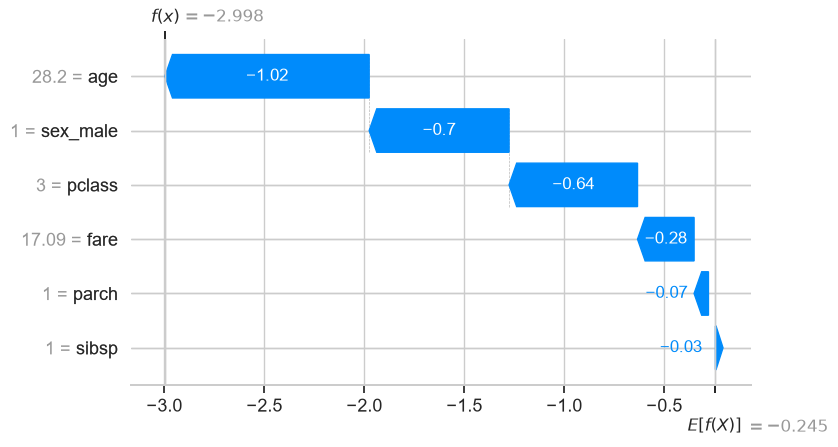

In [31]:
import shap

explanation = shap.Explanation(
    values=shap_values[row],
    base_values=explainer.expected_value,
    data=X_test.iloc[row],
    feature_names=X_test.columns
)

shap.plots.waterfall(explanation)


Write model predicted this passenger incorrectly with high confidence. The prediction was mainly driven by sex_male, pclass, and fare, whose SHAP contributions pushed the model toward the predicted class. Although these features provided strong evidence in that direction, the actual outcome was different, showing that the model can make confident errors when the available features do not capture all factors affecting the passenger's survival.

==> The model predicted this passenger incorrectly with high confidence. The prediction was mainly driven by sex_male, pclass, and fare, whose SHAP contributions pushed the model toward the predicted class. Although these features provided strong evidence in that direction, the actual outcome was different, showing that the model can make confident errors when the available features do not capture all factors affecting the passenger's survival.

•	State one thing you would investigate next as a result.

==> I would investigate other passenger information that is not included in the model, to understand why these strong feature signals led to an incorrect prediction.